<a href="https://colab.research.google.com/github/psampatganesh27-debug/California-housing-predictions/blob/main/housing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


In [ ]:
housing = fetch_california_housing(as_frame=True)

# We'll put all our features and the target into one big DataFrame
df = housing.frame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

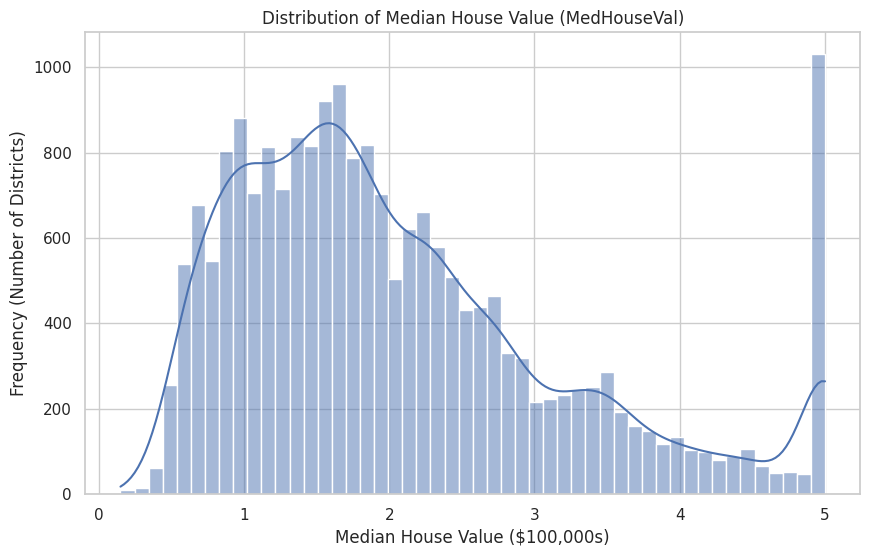

In [ ]:
# Setting the style
sns.set(style="whitegrid")

# Creating a histogram for the median house value
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Value (MedHouseVal)')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency (Number of Districts)')
plt.show()

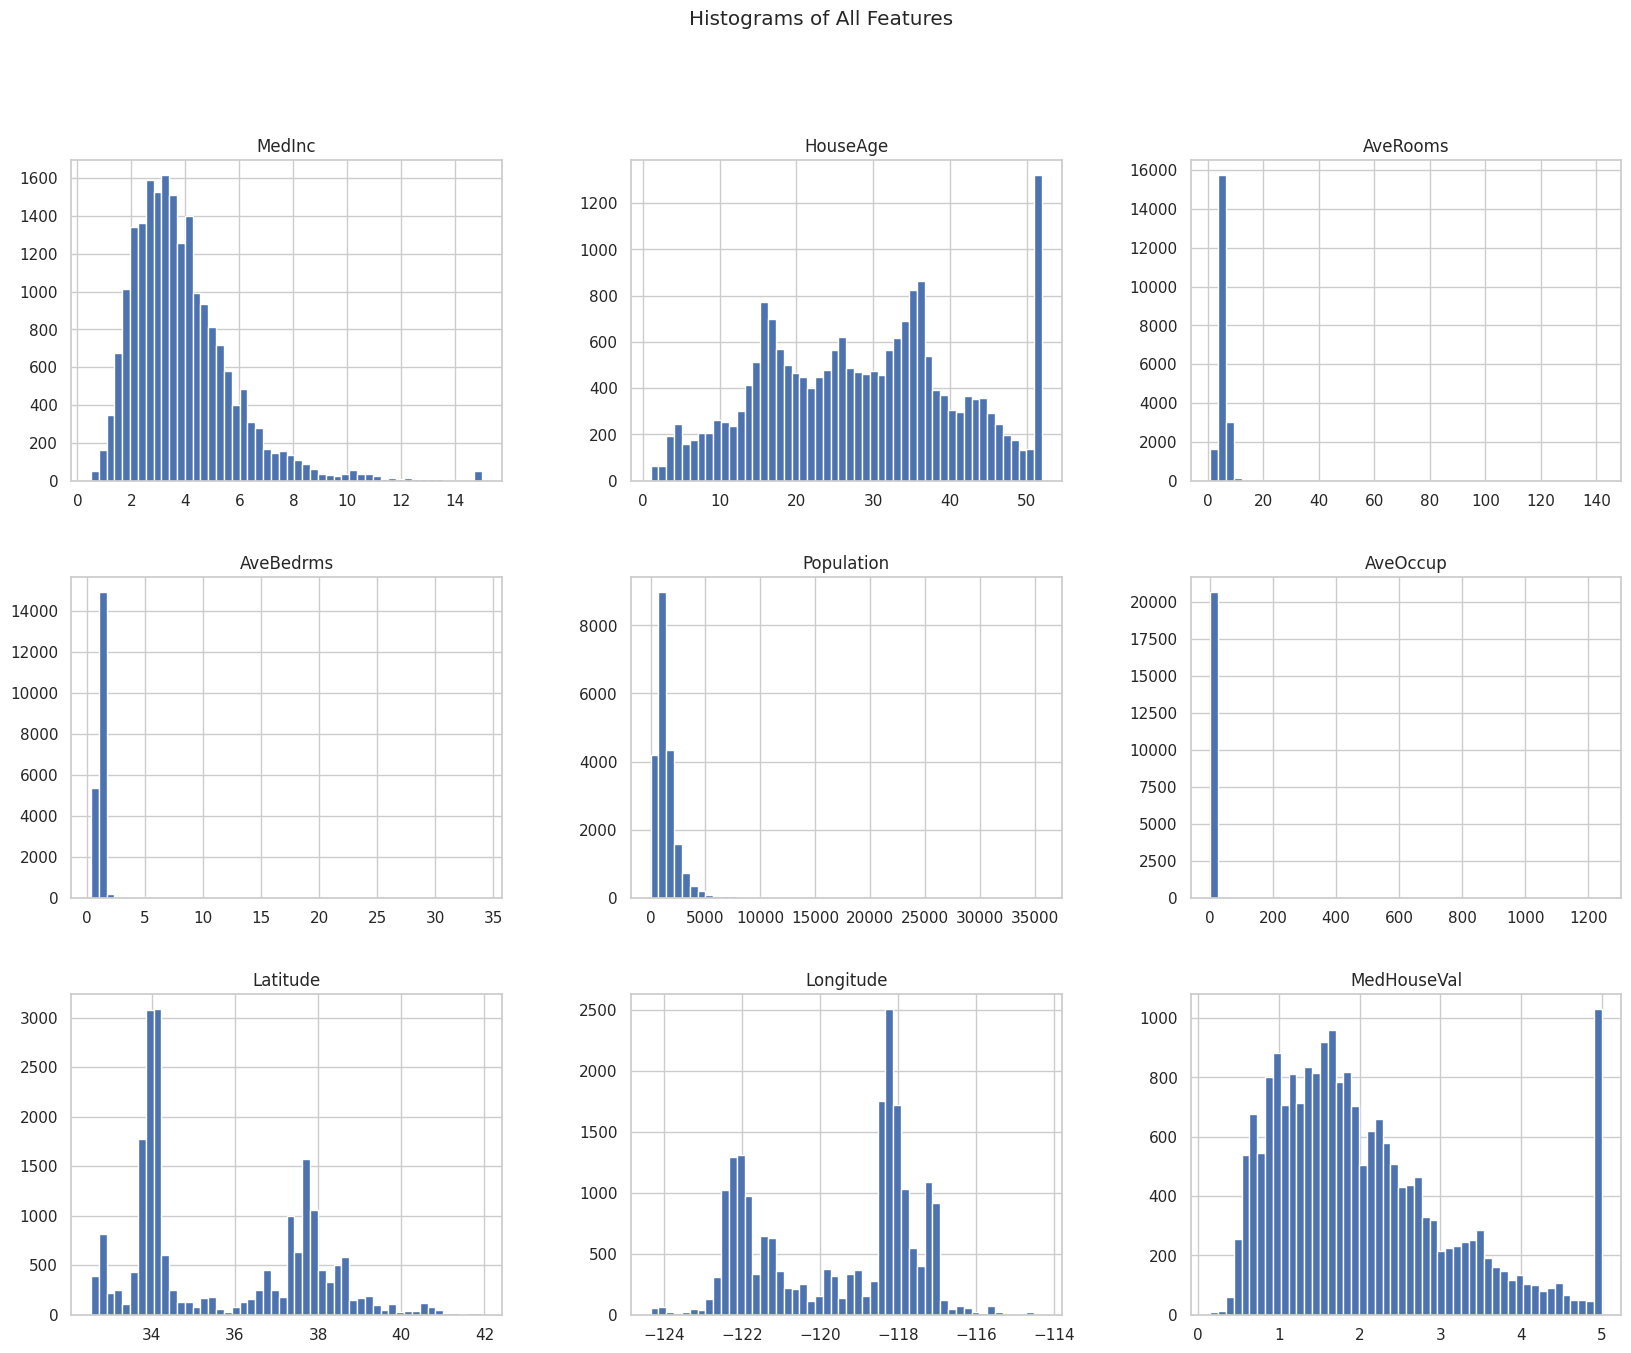

In [ ]:
# Plotting histograms for all numerical features
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of All Features')
plt.show()

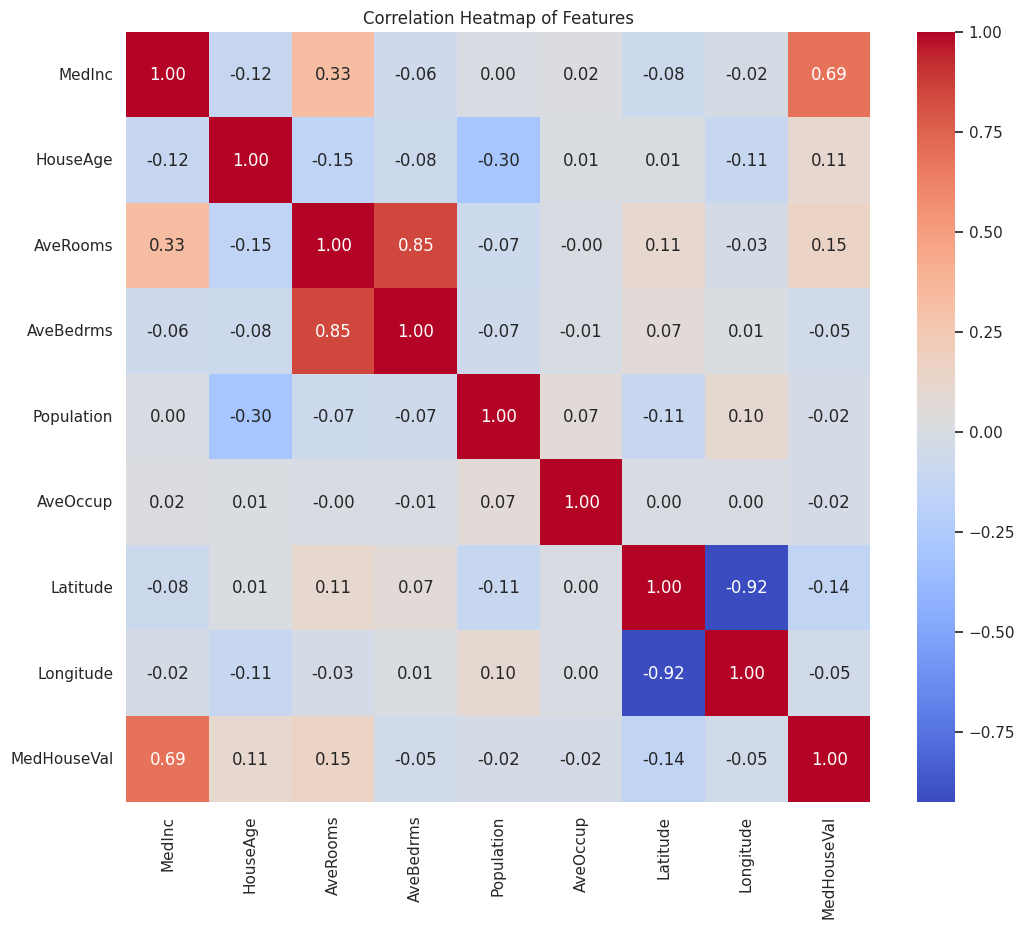

In [ ]:
# Calculate correlations
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# 'df' is our complete dataset from before
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(f"Total rows in original data: {len(df)}")
print(f"Rows in training set: {len(train_set)}")
print(f"Rows in test set: {len(test_set)}")

Total rows in original data: 20640
Rows in training set: 16512
Rows in test set: 4128


In [13]:
# Creating a copy of the training set for our work
housing = train_set.copy()

# 1. Creating the 'housing_labels' (the 'answer')
housing_labels = housing['MedHouseVal'].copy()

# 2. Creating the 'housing_features' (the 'clues')
housing_features = housing.drop('MedHouseVal', axis=1)

# Let's check the first few rows of our new feature table
housing_features.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# This is our data preparation 'assembly line'
# It just has one step for now: 'std_scaler'
data_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

# 'fit_transform' learns the scaling rules from the data and applies them
housing_features_prepared = data_pipeline.fit_transform(housing_features)

In [15]:
# The output is a NumPy array, so we'll just look at the first 5 rows
housing_features_prepared[:5]

array([[-0.326196  ,  0.34849025, -0.17491646, -0.20836543,  0.76827628,
         0.05137609, -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, -0.12853018, -0.09890135,
        -0.11736222, -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, -0.25753771, -0.44981806,
        -0.03227969, -0.46014647, -0.44760309],
       [-1.01786438,  0.58654547, -0.60001532, -0.14515634, -0.00743434,
         0.07750687, -1.38217186,  1.23269811],
       [-0.17148831,  1.14200767,  0.3490073 ,  0.08662432, -0.48587717,
        -0.06883176,  0.5320839 , -0.10855122]])